In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import numpy as np
import matplotlib.pyplot as plt
import pickle

import sys
sys.path.append("../../../../")


from src.difsched.config import getEnvConfig, visualizeEnvConfig
from src.difsched.env.Hybrid import createEnv
from src.difsched.env.Hybrid.Helpers.WirelessModel import WirelessModel
from src.difsched.agents.mdp import MdpKernel
from src.difsched.env.Hybrid.PolicySimulator import PolicySimulator

In [3]:
def simHelper(env, envParams):   
    obvMode = "predicted"
    num_windows = 10000
    N_episodes = 50

    sub_agents_idx = envParams['sub_agents_idx'][0][0]
    with open(f'Agents/Agents/MdpPolicy/mdp_config{sub_agents_idx}.pkl', 'rb') as f:
        mdpKernelParams = pickle.load(f)
    mdpPolicyDeter = MdpKernel()
    mdpPolicyDeter.load_policy(mdpKernelParams, policyMode="deterministic", randomR=False)

    policySimulator = PolicySimulator(env)
    policySimulator.setupModes(obvMode=obvMode, mode="test", type="data")
    # =========== MdpDeter ===========  
    policySimulator.loadPolicies([mdpPolicyDeter], [[0,1,2,3]])
    simResultMdpDeter = policySimulator.runSimulation(
        num_windows=num_windows, N_episodes=N_episodes, verbose=True)
    return simResultMdpDeter

In [ ]:
results = {}
num_simulations = 10

for configIdx in [4,5]:
    envParams = getEnvConfig(configIdx)
    visualizeEnvConfig(envParams)
    trafficDataParentPath = f'Datasets/TrafficDataset/TrafficData'
    env = createEnv(envParams, trafficDataParentPath)

    # Run 50 simulations and collect average rewards
    simResultMdpDeter = simHelper(env, envParams)
    avg_reward = simResultMdpDeter['rewardRecord']

    # Calculate mean and variance
    mean_reward = np.mean(avg_reward)
    var_reward = np.var(avg_reward)
    std_reward = np.std(avg_reward)
    
    print(f"Config {configIdx}: Mean reward = {mean_reward:.6f}, Variance = {var_reward:.6f}, Std = {std_reward:.6f}")

    # Store results with mean and variance
    results[f"{envParams['sigma_list'][0]}->{envParams['sub_agents_idx'][0][0]}"] = {
        'mean': mean_reward,
        'variance': var_reward,
        'std': std_reward,
        'all_rewards': avg_reward   
    }

ValueError: Invalid configIdx: 4

SIMULATION RESULTS SUMMARY
0.05->0:
  Mean:     0.249528
  Variance: 0.004551
  Std Dev:  0.067463

0.05->2:
  Mean:     0.224141
  Variance: 0.020870
  Std Dev:  0.144466



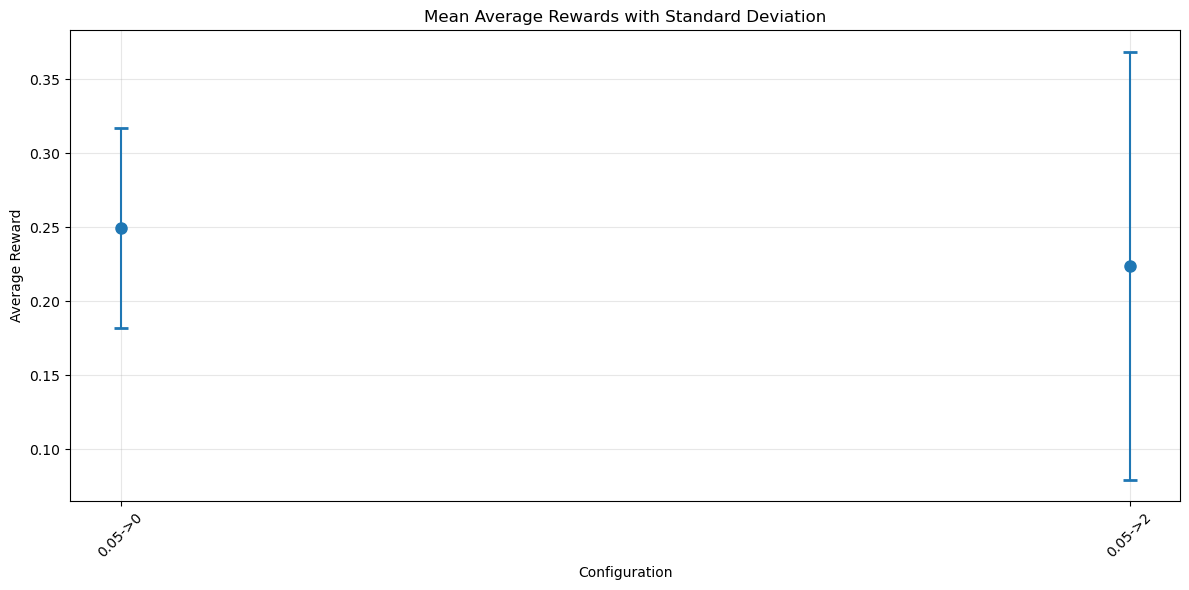

In [4]:
print("=" * 60)
print("SIMULATION RESULTS SUMMARY")
print("=" * 60)

for label, stats in results.items():
    print(f"{label}:")
    print(f"  Mean:     {stats['mean']:.6f}")
    print(f"  Variance: {stats['variance']:.6f}")
    print(f"  Std Dev:  {stats['std']:.6f}")
    print()

# Optional: Create a summary plot comparing means across configurations
config_labels = list(results.keys())
means = [results[label]['mean'] for label in config_labels]
stds = [results[label]['std'] for label in config_labels]

plt.figure(figsize=(12, 6))
plt.errorbar(range(len(config_labels)), means, yerr=stds, fmt='o', capsize=5, capthick=2, markersize=8)
plt.xticks(range(len(config_labels)), config_labels, rotation=45)
plt.xlabel('Configuration')
plt.ylabel('Average Reward')
plt.title('Mean Average Rewards with Standard Deviation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()